<a href="https://colab.research.google.com/github/greypen2006/biophilic-design/blob/main/OLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#This tells python to draw the graphs "inline" - in the notebook
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm
from math import sqrt
from numpy.random import seed
from numpy.random import randn
from numpy import mean
from scipy.stats import sem
import statistics
import seaborn as sns
from IPython.display import display, Math, Latex, display_latex
import plotly.express as px
import pylab
import pandas as pd
import numpy as np
# make the plots (graphs) a little wider by default
pylab.rcParams['figure.figsize'] = (10., 8.)
sns.set(font_scale=1.5)
sns.set_style("white")

    start with running an OLS - plot residuals vs fitted values

    Look for patterns - funnel shapes(residuals increase with fitted values) indicate heteroscedasticity

    Choose weights based on the pattern:

    If variance ↑ with fitted values: weights = 1/fitted²

    If variance ↑ with predictor X: weights = 1/X²

    If variance ↑ with third variable Z: weights = 1/Z

    For complex patterns: model variance with auxiliary regression

    Run WLS and compare results - Check if WLS changes coefficients and reduces standard errors

In [ ]:
from google.colab import files
uploaded=files.upload()


Saving rent_prices.csv to rent_prices (1).csv
Saving weekly_income_cleaned.csv to weekly_income_cleaned (1).csv
Saving ethnicity_cleaned.csv to ethnicity_cleaned (1).csv
Saving PubCount(Sheet1).csv to PubCount(Sheet1) (1).csv
Saving crime_cleaned_final.csv to crime_cleaned_final (1).csv
Saving Population.csv to Population (1).csv
Saving unemployment_cleaned.csv to unemployment_cleaned (1).csv


In [ ]:
sex_df=pd.read_csv('Population.csv', skiprows=35, nrows=13)
sex_df.head()

,local authority: county / unitary (as of April 2023),mnemonic,2017,2018,2019,2020,2021,2022,2023,2024
0,Brent,E09000005,172035.0,174420.0,175791.0,174877.0,172954.0,174856.0,178703.0,180473.0
1,Camden,E09000007,112745.0,112981.0,112990.0,112281.0,111280.0,115471.0,115778.0,115907.0
2,Greenwich,E09000011,144020.0,145791.0,147386.0,147838.0,148738.0,150103.0,152034.0,153409.0
3,Hackney,E09000012,136757.0,137823.0,137858.0,137274.0,135851.0,137030.0,138971.0,139603.0
4,Hammersmith and Fulham,E09000013,97539.0,98619.0,98936.0,98125.0,97403.0,99119.0,100386.0,101423.0


In [ ]:
rent_df=pd.read_csv('rent_prices.csv')
rent_df.head()

,Borough,Mean_Monthly_Rent,2025-2024,2024-2023,2023-2022,2022-2021,2019-2018,2018-2017,2016-2017
0,Brent,1702,2006,2156,1578,1482,1575,1561,1558
1,Camden,2240,2615,2202,2383,2076,2416,1939,2053
2,Greenwich,1547,1866,1740,1557,1478,1385,1435,1370
3,Hackney,1976,2478,2191,1997,1746,1841,1825,1757
4,Hammersmith and Fulham,2141,2516,2418,2270,2019,2055,1737,1975


In [ ]:
income_df=pd.read_csv('weekly_income_cleaned.csv')
income_df.head()

,Year,Brent,Camden,Greenwich,Hackney,Hammersmith and Fulham,Islington,Kensington and Chelsea,Lambeth,Southwark,Tower Hamlets,Westminster
0,2017,471.0,614.3,553.0,558.1,651.1,646.1,784.4,594.6,587.1,592.0,730.8
1,2018,479.9,634.4,566.0,555.4,682.0,687.7,670.6,617.1,589.4,627.6,757.1
2,2019,524.0,662.0,579.5,574.9,728.0,699.1,763.7,634.8,628.0,688.9,703.9
3,2020,531.8,623.0,573.1,574.9,713.1,690.1,802.0,670.8,620.9,665.0,701.1
4,2021,555.7,695.0,618.3,576.8,727.0,670.7,763.6,681.2,637.8,685.2,771.1


In [ ]:
race_df=pd.read_csv('ethnicity_cleaned.csv')
race_df['EthnicGroupCategory'] = race_df['EthnicGroupCategory'].replace({
    'White': 1,
    'Asian': 2,
    'Black': 3,
    'Mixed/Other': 4,
    'Mixed': 4, # Assuming 'Mixed' also maps to 4
    'Other': 4  # Assuming 'Other' also maps to 4
})
race_df.head()

,BoroughCode,BoroughName,Year,EthnicGroupCategory,Count
0,E09000011,Greenwich,2020,1,158000.0
1,E09000012,Hackney,2020,1,167000.0
2,E09000013,Hammersmith and Fulham,2020,1,122000.0
3,E09000019,Islington,2020,1,177000.0
4,E09000020,Kensington and Chelsea,2020,1,109000.0


In [ ]:
# The previous line caused an InvalidIndexError due to incorrect indexing syntax and non-existent columns.
# The columns 'White_Cl', 'Asian_Cl', 'Black_Cl', 'Mixed/Other_Cl', 'Total_Cl' do not exist in race_df.
# If you intended to filter rows where 'EthnicGroupCategory' was 'Total' before the numeric conversion,
# that step has already passed. If you mean to filter based on a numeric value in 'EthnicGroupCategory',
# you would use race_df[race_df['EthnicGroupCategory'] != some_numeric_value].

# For now, I'll just display the head of the DataFrame.
race_df.head()

,BoroughCode,BoroughName,Year,EthnicGroupCategory,Count
0,E09000011,Greenwich,2020,1,158000.0
1,E09000012,Hackney,2020,1,167000.0
2,E09000013,Hammersmith and Fulham,2020,1,122000.0
3,E09000019,Islington,2020,1,177000.0
4,E09000020,Kensington and Chelsea,2020,1,109000.0


In [ ]:
pub_df=pd.read_csv('PubCount(Sheet1).csv')
pub_df.head()

,BoroughName,2017,2018,2019,2020,2021,2022,2023
0,Brent,70,65,65,55,60,70,70
1,Camden,245,240,235,245,240,240,235
2,Greenwich,75,65,75,65,65,75,70
3,Hackney,235,225,200,190,200,205,205
4,Hammersmith and Fulham,95,90,90,100,100,100,95


In [ ]:
crime_df=pd.read_csv('crime_cleaned_final.csv')
crime_df.head()

,MajorText,MinorText,BoroughName,YearMonth,CrimeCount,Year,mnemonic,Population,CrimeRate
0,ARSON AND CRIMINAL DAMAGE,ARSON,Brent,201701,3,2017,E09000005,342439,0.000876
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Brent,201701,155,2017,E09000005,342439,0.045264
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Brent,201701,56,2017,E09000005,342439,0.016353
3,BURGLARY,DOMESTIC BURGLARY,Brent,201701,195,2017,E09000005,342439,0.056944
4,BURGLARY,RES BURGLARY OF A HOME,Brent,201701,0,2017,E09000005,342439,0.000000


In [ ]:
sexual_crime_df = crime_df[crime_df['MajorText'] == 'SEXUAL OFFENCES']
sexual_crime_df.head()

,MajorText,MinorText,BoroughName,YearMonth,CrimeCount,Year,mnemonic,Population,CrimeRate
17,SEXUAL OFFENCES,OTHER SEXUAL OFFENCES,Brent,201701,26,2017,E09000005,342439,0.007593
18,SEXUAL OFFENCES,RAPE,Brent,201701,15,2017,E09000005,342439,0.004380
49,SEXUAL OFFENCES,OTHER SEXUAL OFFENCES,Camden,201701,27,2017,E09000007,218833,0.012338
50,SEXUAL OFFENCES,RAPE,Camden,201701,13,2017,E09000007,218833,0.005941
81,SEXUAL OFFENCES,OTHER SEXUAL OFFENCES,Greenwich,201701,22,2017,E09000011,282376,0.007791


In [ ]:
job_df=pd.read_csv('unemployment_cleaned.csv')
job_df.head()
#

,local authority: district / unitary (as of April 2023),mnemonic,Jul 2016-Jun 2017,Conf,Jul 2017-Jun 2018,Conf.1,Jul 2018-Jun 2019,Conf.2,Jul 2019-Jun 2020,Conf.3,Jul 2020-Jun 2021,Conf.4,Jul 2021-Jun 2022,Conf.5,Jul 2022-Jun 2023,Conf.6,Jul 2023-Jun 2024,Conf.7,Jul 2024-Jun 2025,Conf.8
0,Brent,E09000005,6.6,1.5,5.9,1.4,4.1,1.4,5.9,1.9,7.6,2.1,5.4,1.8,7.3,3.1,5.5,2.3,8.2,3.0
1,Camden,E09000007,5.3,1.3,5.0,1.4,4.8,1.6,4.0,1.4,5.3,1.7,3.8,1.4,4.0,1.7,6.3,2.2,5.0,2.4
2,Greenwich,E09000011,6.1,1.4,5.5,1.3,4.3,1.3,4.9,1.4,6.6,1.5,5.9,1.5,4.7,1.5,4.1,1.4,6.4,2.3
3,Hackney,E09000012,5.7,1.4,5.7,1.4,5.0,1.5,5.4,1.6,6.1,1.8,4.3,1.5,4.3,1.7,4.4,1.7,5.3,1.8
4,Hammersmith and Fulham,E09000013,5.8,1.4,5.6,1.5,5.8,1.8,4.5,1.5,5.8,1.7,4.7,1.7,3.9,1.7,5.7,2.1,4.3,1.9


# Task
The task is to prepare the following dataframes: `sex_df`, `rent_df`, `income_df`, `race_df`, `pub_df`, `sexual_crime_df`, and `job_df`, and then merge them into a single master dataframe named `merged_df`.

Here's a detailed breakdown of the preparation steps for each dataframe:

*   **`sex_df`**:
    *   Rename 'Borough' to 'BoroughName' and 'All ages' to 'Female_Population'.
    *   **Add a 'Year' column and assign a placeholder year (2023) to all entries, as the original dataframe lacks a 'Year' column.**

*   **`rent_df`**:
    *   Rename 'Borough' to 'BoroughName'.
    *   Melt the yearly rent columns (e.g., '2025-2024') into two new columns: 'Year_Range' and 'Rent_Price'.
    *   Extract the end year from 'Year_Range' (e.g., '2024' from '2025-2024') and convert it to an integer, assigning this to a new 'Year' column.
    *   The 'Mean_Monthly_Rent' column will not be used in the final merged output.

*   **`income_df`**:
    *   Melt the borough-specific income columns (all columns except 'Year') into 'BoroughName' and 'Weekly_Income', retaining the 'Year' column.

*   **`race_df`**:
    *   Group by 'BoroughName' and 'Year'.
    *   For each group, identify the `EthnicGroupCategory` with the highest 'Count' and create a new column named 'Dominant_Ethnicity' to represent the primary ethnicity for that borough and year.

*   **`pub_df`**:
    *   Melt the year columns (e.g., '2017') into a 'Year' column and a 'Pub_Count' column, keeping 'BoroughName'.

*   **`sexual_crime_df`**:
    *   Group by 'BoroughName' and 'Year'.
    *   Sum the 'CrimeCount' for each group to get the 'Sexual_Crime_Count' for each borough and year.

*   **`job_df`**:
    *   Rename 'local authority: district / unitary (as of April 2023)' to 'BoroughName'.
    *   Melt the year range columns (e.g., 'Jul 2016-Jun 2017') along with their corresponding 'Conf' columns.
    *   Extract the end year from the melted year ranges (e.g., '2017' from 'Jul 2016-Jun 2017') and convert it to an integer, assigning this to a new 'Year' column.
    *   Drop the 'Conf' columns and rename the value column from the melt operation to 'Unemployment_Rate'.

After preparing each dataframe, perform a series of inner merges on 'BoroughName' and 'Year' to combine them into a single `merged_df`.

Finally, from `merged_df`, select and rename the following columns:
*   'Female_Population' to 'femalepop'
*   'Rent_Price' to 'rent price'
*   'Weekly_Income' to 'weekly income'
*   'Dominant_Ethnicity' to 'ethnicity'
*   'Pub_Count' to 'pub count'
*   'Sexual_Crime_Count' to 'sexual crime'
*   'Unemployment_Rate' to 'unemployment'

Display the head and information (`.info()`) of the final `merged_df`.

## Prepare `sex_df`

### Subtask:
Rename the 'Borough' column to 'BoroughName' and 'All ages' to 'Female_Population'. Add a 'Year' column and assign a placeholder year (2023) to all entries.


**Reasoning**:
Rename the specified columns and add a new 'Year' column with a placeholder value to `sex_df` as per the subtask instructions.



In [ ]:
# Rename the 'local authority...' column to 'BoroughName'
sex_df = sex_df.rename(columns={'local authority: county / unitary (as of April 2023)': 'BoroughName'})

# Identify columns that represent years for melting
year_cols = [str(year) for year in range(2017, 2025)] # Covers 2017-2024 as per sex_df.head()

# Melt the DataFrame to transform year columns into a single 'Year' column and 'Female_Population'
sex_df_melted = sex_df.melt(
    id_vars=['BoroughName', 'mnemonic'], # Keep BoroughName and mnemonic as identifier variables during melt
    value_vars=year_cols,
    var_name='Year',
    value_name='Female_Population'
)

# Convert the 'Year' column to integer type
sex_df_melted['Year'] = sex_df_melted['Year'].astype(int)

# Update sex_df to be the melted version, dropping the 'mnemonic' column as it's not needed for the final merge
sex_df = sex_df_melted.drop(columns=['mnemonic'])

sex_df.head()

,BoroughName,Year,Female_Population
0,Brent,2017,172035.0
1,Camden,2017,112745.0
2,Greenwich,2017,144020.0
3,Hackney,2017,136757.0
4,Hammersmith and Fulham,2017,97539.0


## Prepare `rent_df`

### Subtask:
Rename the 'Borough' column to 'BoroughName'. Melt the yearly rent columns (e.g., '2025-2024') into two new columns: 'Year_Range' and 'Rent_Price'. Extract the end year from 'Year_Range' and convert it to an integer, assigning this to a new 'Year' column. The 'Mean_Monthly_Rent' column will not be used in the final merged output.

**Reasoning**:
The next step is to rename the 'Borough' column to 'BoroughName' in the `rent_df` DataFrame as per the subtask instructions.



In [ ]:
rent_df = rent_df.rename(columns={'Borough': 'BoroughName'})
rent_df.head()

,BoroughName,Mean_Monthly_Rent,2025-2024,2024-2023,2023-2022,2022-2021,2019-2018,2018-2017,2016-2017
0,Brent,1702,2006,2156,1578,1482,1575,1561,1558
1,Camden,2240,2615,2202,2383,2076,2416,1939,2053
2,Greenwich,1547,1866,1740,1557,1478,1385,1435,1370
3,Hackney,1976,2478,2191,1997,1746,1841,1825,1757
4,Hammersmith and Fulham,2141,2516,2418,2270,2019,2055,1737,1975


**Reasoning**:
I need to melt the year-range columns in `rent_df` to transform the data into a long format, as specified in the subtask. This involves identifying the columns to melt and renaming the new 'variable' and 'value' columns to 'Year_Range' and 'Rent_Price', respectively.



In [ ]:
rent_df_melted = rent_df.melt(id_vars=['BoroughName'],
                               value_vars=[col for col in rent_df.columns if '-' in col],
                               var_name='Year_Range',
                               value_name='Rent_Price')
rent_df_melted.head()

,BoroughName,Year_Range,Rent_Price
0,Brent,2025-2024,2006
1,Camden,2025-2024,2615
2,Greenwich,2025-2024,1866
3,Hackney,2025-2024,2478
4,Hammersmith and Fulham,2025-2024,2516


**Reasoning**:
Now I need to extract the end year from the 'Year_Range' column in `rent_df_melted` and convert it to an integer, storing it in a new 'Year' column, as specified in the subtask.



In [ ]:
rent_df_melted['Year'] = rent_df_melted['Year_Range'].apply(lambda x: int(x.split('-')[1]))
rent_df_melted.head()

,BoroughName,Year_Range,Rent_Price,Year
0,Brent,2025-2024,2006,2024
1,Camden,2025-2024,2615,2024
2,Greenwich,2025-2024,1866,2024
3,Hackney,2025-2024,2478,2024
4,Hammersmith and Fulham,2025-2024,2516,2024


**Reasoning**:
The 'Mean_Monthly_Rent' column is not needed for the final merged output as specified in the subtask. I will drop it from the original `rent_df` and keep `rent_df_melted` which already doesn't contain this column. Additionally, the 'Year_Range' column was used to extract the 'Year' and is no longer needed, so it should also be dropped from `rent_df_melted` to finalize its preparation.



In [ ]:
rent_df_melted = rent_df_melted.drop(columns=['Year_Range'])
rent_df_melted.head()

,BoroughName,Rent_Price,Year
0,Brent,2006,2024
1,Camden,2615,2024
2,Greenwich,1866,2024
3,Hackney,2478,2024
4,Hammersmith and Fulham,2516,2024


## Prepare `income_df`

### Subtask:
Melt the borough-specific income columns (all columns except 'Year') into 'BoroughName' and 'Weekly_Income', retaining the 'Year' column.

**Reasoning**:
I need to melt the `income_df` to transform borough-specific income columns into 'BoroughName' and 'Weekly_Income', while retaining the 'Year' column, as outlined in the subtask.



In [ ]:
income_df_melted = income_df.melt(id_vars=['Year'], var_name='BoroughName', value_name='Weekly_Income')
income_df_melted.head()

,Year,BoroughName,Weekly_Income
0,2017,Brent,471.0
1,2018,Brent,479.9
2,2019,Brent,524.0
3,2020,Brent,531.8
4,2021,Brent,555.7


## Prepare `race_df`

### Subtask:
Group by 'BoroughName' and 'Year'.
For each group, identify the `EthnicGroupCategory` with the highest 'Count' and create a new column named 'Dominant_Ethnicity' to represent the primary ethnicity for that borough and year.

**Reasoning**:
The markdown block for preparing `race_df` has been displayed. Now, I need to implement the subtask of grouping `race_df` by 'BoroughName' and 'Year', then finding the `EthnicGroupCategory` with the maximum 'Count' within each group to establish the 'Dominant_Ethnicity'.



In [ ]:
idx = race_df.groupby(['BoroughName', 'Year'])['Count'].idxmax()
race_df_dominant_ethnicity = race_df.loc[idx, ['BoroughName', 'Year', 'EthnicGroupCategory']]
race_df_dominant_ethnicity = race_df_dominant_ethnicity.rename(columns={'EthnicGroupCategory': 'Dominant_Ethnicity'})
race_df_dominant_ethnicity.head()

,BoroughName,Year,Dominant_Ethnicity
171,Greenwich,2017,Total
162,Greenwich,2018,Total
153,Greenwich,2019,Total
144,Greenwich,2020,Total
172,Hackney,2017,Total


**Reasoning**:
The previous output showed 'Total' as the dominant ethnicity, which indicates that the 'Total' category, which was not mapped to a numeric value, still exists in the `race_df` and is being selected due to its high count. To correctly identify the dominant ethnicity among the specified categories (1, 2, 3, 4), I need to filter out rows where `EthnicGroupCategory` is 'Total' before grouping and finding the maximum count. The original `race_df` was already processed to convert specific ethnic groups to numeric categories, so I need to explicitly exclude 'Total' entries.



In [ ]:
race_df_filtered = race_df[race_df['EthnicGroupCategory'] != 'Total']
idx = race_df_filtered.groupby(['BoroughName', 'Year'])['Count'].idxmax()
race_df_dominant_ethnicity = race_df_filtered.loc[idx, ['BoroughName', 'Year', 'EthnicGroupCategory']]
race_df_dominant_ethnicity = race_df_dominant_ethnicity.rename(columns={'EthnicGroupCategory': 'Dominant_Ethnicity'})
race_df_dominant_ethnicity.head()

,BoroughName,Year,Dominant_Ethnicity
27,Greenwich,2017,1
18,Greenwich,2018,1
9,Greenwich,2019,1
0,Greenwich,2020,1
28,Hackney,2017,1


## Prepare `pub_df`

### Subtask:
Melt the year columns (e.g., '2017') into a 'Year' column and a 'Pub_Count' column, keeping 'BoroughName'.

**Reasoning**:
I need to melt the `pub_df` to transform the year columns into a 'Year' column and a 'Pub_Count' column, while retaining the 'BoroughName', as outlined in the subtask.



In [ ]:
pub_df_melted = pub_df.melt(id_vars=['BoroughName'], var_name='Year', value_name='Pub_Count')
pub_df_melted['Year'] = pub_df_melted['Year'].astype(int)
pub_df_melted.head()

,BoroughName,Year,Pub_Count
0,Brent,2017,70
1,Camden,2017,245
2,Greenwich,2017,75
3,Hackney,2017,235
4,Hammersmith and Fulham,2017,95


## Prepare `sexual_crime_df`

### Subtask:
Group by 'BoroughName' and 'Year'.
Sum the 'CrimeCount' for each group to get the 'Sexual_Crime_Count' for each borough and year.

**Reasoning**:
I need to group `sexual_crime_df` by 'BoroughName' and 'Year', then sum the 'CrimeCount' for each group to calculate 'Sexual_Crime_Count', as specified in the subtask.



In [138]:
sexual_crime_df_agg = sexual_crime_df.groupby(['BoroughName', 'Year'])['CrimeRate'].sum().reset_index()
sexual_crime_df_agg = sexual_crime_df_agg.rename(columns={'CrimeRate': 'Sexual_Crime_Rate'})
sexual_crime_df_agg.head()

,BoroughName,Year,Sexual_Crime_Rate
0,Brent,2017,0.181346
1,Brent,2018,0.182893
2,Brent,2019,0.187667
3,Brent,2020,0.170936
4,Brent,2021,0.193369


## Prepare `job_df`

### Subtask:
Rename 'local authority: district / unitary (as of April 2023)' to 'BoroughName'.
Melt the year range columns (e.g., 'Jul 2016-Jun 2017') along with their corresponding 'Conf' columns.
Extract the end year from the melted year ranges (e.g., '2017' from 'Jul 2016-Jun 2017') and convert it to an integer, assigning this to a new 'Year' column.
Drop the 'Conf' columns and rename the value column from the melt operation to 'Unemployment_Rate'.

## Prepare `job_df`

### Subtask:
Rename 'local authority: district / unitary (as of April 2023)' to 'BoroughName'. Melt the year range columns (e.g., 'Jul 2016-Jun 2017') into a 'Year_Range' column and a 'Unemployment_Rate' column. Extract the end year from 'Year_Range' and convert it to an integer, assigning this to a new 'Year' column. Drop the 'Conf' columns and the 'Year_Range' column.


**Reasoning**:
I need to rename the column 'local authority: district / unitary (as of April 2023)' to 'BoroughName' in `job_df` as per the first instruction of the subtask.



In [139]:
job_df = job_df.rename(columns={'local authority: district / unitary (as of April 2023)': 'BoroughName'})
job_df.head()

,BoroughName,mnemonic,Jul 2016-Jun 2017,Conf,Jul 2017-Jun 2018,Conf.1,Jul 2018-Jun 2019,Conf.2,Jul 2019-Jun 2020,Conf.3,Jul 2020-Jun 2021,Conf.4,Jul 2021-Jun 2022,Conf.5,Jul 2022-Jun 2023,Conf.6,Jul 2023-Jun 2024,Conf.7,Jul 2024-Jun 2025,Conf.8
0,Brent,E09000005,6.6,1.5,5.9,1.4,4.1,1.4,5.9,1.9,7.6,2.1,5.4,1.8,7.3,3.1,5.5,2.3,8.2,3.0
1,Camden,E09000007,5.3,1.3,5.0,1.4,4.8,1.6,4.0,1.4,5.3,1.7,3.8,1.4,4.0,1.7,6.3,2.2,5.0,2.4
2,Greenwich,E09000011,6.1,1.4,5.5,1.3,4.3,1.3,4.9,1.4,6.6,1.5,5.9,1.5,4.7,1.5,4.1,1.4,6.4,2.3
3,Hackney,E09000012,5.7,1.4,5.7,1.4,5.0,1.5,5.4,1.6,6.1,1.8,4.3,1.5,4.3,1.7,4.4,1.7,5.3,1.8
4,Hammersmith and Fulham,E09000013,5.8,1.4,5.6,1.5,5.8,1.8,4.5,1.5,5.8,1.7,4.7,1.7,3.9,1.7,5.7,2.1,4.3,1.9


**Reasoning**:
I need to identify the unemployment rate columns (those containing 'Jul' and a year range, excluding 'Conf' columns) and then melt the `job_df` to transform these columns into 'Year_Range' and 'Unemployment_Rate', while retaining 'BoroughName' and 'mnemonic' as identifier variables.



In [140]:
unemployment_cols = [col for col in job_df.columns if 'Jul' in col and 'Conf' not in col]
job_df_melted = job_df.melt(id_vars=['BoroughName', 'mnemonic'],
                            value_vars=unemployment_cols,
                            var_name='Year_Range',
                            value_name='Unemployment_Rate')
job_df_melted.head()

,BoroughName,mnemonic,Year_Range,Unemployment_Rate
0,Brent,E09000005,Jul 2016-Jun 2017,6.6
1,Camden,E09000007,Jul 2016-Jun 2017,5.3
2,Greenwich,E09000011,Jul 2016-Jun 2017,6.1
3,Hackney,E09000012,Jul 2016-Jun 2017,5.7
4,Hammersmith and Fulham,E09000013,Jul 2016-Jun 2017,5.8


**Reasoning**:
I need to extract the end year from the 'Year_Range' column in `job_df_melted` and convert it to an integer, assigning it to a new 'Year' column, as per the subtask instructions.



In [ ]:
job_df_melted['Year'] = job_df_melted['Year_Range'].apply(lambda x: int(x.split('-')[1].split(' ')[1]))
job_df_melted.head()

,BoroughName,mnemonic,Year_Range,Unemployment_Rate,Year
0,Brent,E09000005,Jul 2016-Jun 2017,6.6,2017
1,Camden,E09000007,Jul 2016-Jun 2017,5.3,2017
2,Greenwich,E09000011,Jul 2016-Jun 2017,6.1,2017
3,Hackney,E09000012,Jul 2016-Jun 2017,5.7,2017
4,Hammersmith and Fulham,E09000013,Jul 2016-Jun 2017,5.8,2017


**Reasoning**:
I need to drop the 'Year_Range' column and the 'mnemonic' column from the `job_df_melted` DataFrame, as these columns are no longer needed after extracting the 'Year' and are not part of the final merged output.



In [ ]:
job_df_melted = job_df_melted.drop(columns=['Year_Range', 'mnemonic'])
job_df_melted.head()

,BoroughName,Unemployment_Rate,Year
0,Brent,6.6,2017
1,Camden,5.3,2017
2,Greenwich,6.1,2017
3,Hackney,5.7,2017
4,Hammersmith and Fulham,5.8,2017


## Merge All DataFrames

### Subtask:
Perform a series of inner merge operations to combine all prepared dataframes into a single master dataframe named `merged_df`, using 'BoroughName' and 'Year' as common keys.


**Reasoning**:
I need to begin the merging process by combining `sex_df` and `rent_df_melted` into `merged_df` using an inner merge on 'BoroughName' and 'Year', as per the first instruction of the subtask.



**Reasoning**:
Now I need to merge the currently formed `merged_df` with `income_df_melted` using an inner merge on 'BoroughName' and 'Year', as per the next instruction in the subtask.



**Reasoning**:
Now I need to merge the `merged_df` with `race_df_dominant_ethnicity` using an inner merge on 'BoroughName' and 'Year', as specified in the subtask instructions.



In [142]:
import pandas as pd
from itertools import product

# Clean 'BoroughName' in each dataframe by stripping whitespace
sex_df['BoroughName'] = sex_df['BoroughName'].str.strip()
rent_df_melted['BoroughName'] = rent_df_melted['BoroughName'].str.strip()
income_df_melted['BoroughName'] = income_df_melted['BoroughName'].str.strip()
race_df_dominant_ethnicity['BoroughName'] = race_df_dominant_ethnicity['BoroughName'].str.strip()
pub_df_melted['BoroughName'] = pub_df_melted['BoroughName'].str.strip()
sexual_crime_df_agg['BoroughName'] = sexual_crime_df_agg['BoroughName'].str.strip()
job_df_melted['BoroughName'] = job_df_melted['BoroughName'].str.strip()

# Consolidate all unique BoroughNames from all dataframes
all_boroughs = pd.concat([
    sex_df['BoroughName'],
    rent_df_melted['BoroughName'],
    income_df_melted['BoroughName'],
    race_df_dominant_ethnicity['BoroughName'],
    pub_df_melted['BoroughName'],
    sexual_crime_df_agg['BoroughName'],
    job_df_melted['BoroughName']
]).unique()

# Filter out non-borough entries from all_boroughs
non_borough_entries = ['Column Total', 'Population estimates - local authority based by five year age band'] # Add any other identified non-borough entries
all_boroughs = [b for b in all_boroughs if b not in non_borough_entries]

# Define the years to include
years_to_include = pd.Series(range(2017, 2025)) # 2017 to 2024 inclusive

# Create a master dataframe with all borough-year combinations
master_combinations = pd.DataFrame(list(product(all_boroughs, years_to_include)), columns=['BoroughName', 'Year'])

# Start merged_df with the master combinations
merged_df = master_combinations

# Perform left merges with each prepared dataframe
merged_df = pd.merge(merged_df, sex_df, on=['BoroughName', 'Year'], how='left')
merged_df = pd.merge(merged_df, rent_df_melted, on=['BoroughName', 'Year'], how='left')
merged_df = pd.merge(merged_df, income_df_melted, on=['BoroughName', 'Year'], how='left')
merged_df = pd.merge(merged_df, race_df_dominant_ethnicity, on=['BoroughName', 'Year'], how='left')
merged_df = pd.merge(merged_df, pub_df_melted, on=['BoroughName', 'Year'], how='left')
merged_df = pd.merge(merged_df, sexual_crime_df_agg, on=['BoroughName', 'Year'], how='left')

# --- Fix for job_df_melted not having 'Year' column ---
# Ensure job_df_melted has the 'Year' column and unnecessary columns are dropped
# Re-extract the end year from 'Year_Range' as the kernel state indicates it's missing
job_df_melted['Year'] = job_df_melted['Year_Range'].apply(lambda x: int(x.split('-')[1].split(' ')[1]))
# Re-drop the 'Year_Range' and 'mnemonic' columns
job_df_melted = job_df_melted.drop(columns=['Year_Range', 'mnemonic'])
# --- End Fix ---

merged_df = pd.merge(merged_df, job_df_melted, on=['BoroughName', 'Year'], how='left')

# Rename columns as specified in the task
merged_df = merged_df.rename(columns={
    'Female_Population': 'femalepop',
    'Rent_Price': 'rent price',
    'Weekly_Income': 'weekly income',
    'Dominant_Ethnicity': 'ethnicity',
    'Pub_Count': 'pub count',
    'Sexual_Crime_Rate': 'sexual crime', # Corrected column name for sexual crime
    'Unemployment_Rate': 'unemployment'
})

# Display head and info of the final merged_df
display(merged_df.head())
display(merged_df.info())

,BoroughName,Year,femalepop,rent price,weekly income,ethnicity,pub count,sexual crime,unemployment
0,Brent,2017,172035.0,1561.0,471.0,NaN,70.0,0.181346,6.6
1,Brent,2017,172035.0,1558.0,471.0,NaN,70.0,0.181346,6.6
2,Brent,2018,174420.0,1575.0,479.9,NaN,65.0,0.182893,5.9
3,Brent,2019,175791.0,NaN,524.0,NaN,65.0,0.187667,4.1
4,Brent,2020,174877.0,NaN,531.8,NaN,55.0,0.170936,5.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BoroughName    107 non-null    object 
 1   Year           107 non-null    int64  
 2   femalepop      99 non-null     float64
 3   rent price     77 non-null     float64
 4   weekly income  99 non-null     float64
 5   ethnicity      45 non-null     object 
 6   pub count      87 non-null     float64
 7   sexual crime   99 non-null     float64
 8   unemployment   99 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 7.7+ KB


None

In [ ]:
merged_df.tail()

,BoroughName,Year,femalepop,rent price,weekly income,ethnicity,pub count,sexual crime,unemployment
118,Westminister,2020,NaN,NaN,NaN,NaN,425.0,NaN,NaN
119,Westminister,2021,NaN,NaN,NaN,NaN,430.0,NaN,NaN
120,Westminister,2022,NaN,NaN,NaN,NaN,425.0,NaN,NaN
121,Westminister,2023,NaN,NaN,NaN,NaN,435.0,NaN,NaN
122,Westminister,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
merged_df

,BoroughName,Year,femalepop,rent price,weekly income,ethnicity,pub count,sexual crime,unemployment
0,Brent,2017,172035.0,1561.0,471.0,NaN,70.0,621.0,6.6
1,Brent,2017,172035.0,1558.0,471.0,NaN,70.0,621.0,6.6
2,Brent,2018,174420.0,1575.0,479.9,NaN,65.0,632.0,5.9
3,Brent,2019,175791.0,NaN,524.0,NaN,65.0,652.0,4.1
4,Brent,2020,174877.0,NaN,531.8,NaN,55.0,588.0,5.9
...,...,...,...,...,...,...,...,...,...
118,Westminister,2020,NaN,NaN,NaN,NaN,425.0,NaN,NaN
119,Westminister,2021,NaN,NaN,NaN,NaN,430.0,NaN,NaN
120,Westminister,2022,NaN,NaN,NaN,NaN,425.0,NaN,NaN
121,Westminister,2023,NaN,NaN,NaN,NaN,435.0,NaN,NaN


In [143]:
merged_df.to_csv('merged_df.csv')

In [144]:
files.download('merged_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [145]:
uploaded1=files.upload()

Saving merged_df(2).csv to merged_df(2).csv


In [170]:
mergedDF=pd.read_csv('merged_df(2).csv')
mergedDF.head()

,Unnamed: 0,BoroughName,Year,femalepop,rent price,weekly income,pub count,sexual crime,unemployment
0,0,Brent,2017,172035,1561.0,471.0,70.0,0.181346,6.6
1,1,Brent,2017,172035,1558.0,471.0,70.0,0.181346,6.6
2,2,Brent,2018,174420,1575.0,479.9,65.0,0.182893,5.9
3,3,Brent,2019,175791,NaN,524.0,65.0,0.187667,4.1
4,4,Brent,2020,174877,NaN,531.8,55.0,0.170936,5.9


In [147]:
summary=mergedDF.describe().round(2)
summary=summary.T
summary

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,99.0,49.00,28.72,0.00,24.50,49.00,73.50,98.00
Year,99.0,2020.11,2.44,2017.00,2018.00,2020.00,2022.00,2024.00
femalepop,99.0,132145.21,30375.02,76536.00,108748.50,137274.00,160512.00,180473.00
rent price,77.0,2128.08,543.90,1370.00,1740.00,1997.00,2408.00,3874.00
weekly income,99.0,671.43,87.12,471.00,604.45,670.80,732.35,855.90
pub count,87.0,173.05,98.18,55.00,95.00,155.00,232.50,440.00
sexual crime,99.0,0.29,0.10,0.17,0.23,0.28,0.32,0.71
unemployment,99.0,5.37,0.97,3.50,4.65,5.50,6.00,8.10


In [171]:
def filter_outliers(var):
    q1 = var.quantile(0.25) # calculate the first quartile
    q3 = var.quantile(0.75) # calculate the third quartile
    iqr = q3 - q1 # calculate the interquartile range
    low = q1 - 3*iqr # calculate the lower bound
    high = q3 + 3*iqr # calculate the upper bound
    filtered = mergedDF[(var > low) & (var < high)] # filter  the values that are within the bounds
    dropped_observations= len(var)-len(filtered) # calculate the number of observations that were dropped

    print('Dropped {} observations'.format(dropped_observations))
    return  filtered

mergedDF=filter_outliers(mergedDF['rent price']) # filter outliers from realhrwage


Dropped 22 observations


In [172]:
mergedDF=filter_outliers(mergedDF['femalepop']) # filter outliers from realhrwage

Dropped 0 observations


In [173]:
summary=mergedDF.describe().round(2).T
summary[['count','mean','std','min','25%','50%','75%','max']]

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,77.0,49.14,28.80,0.00,25.00,50.00,73.00,98.00
Year,77.0,2020.29,2.73,2017.00,2017.00,2021.00,2023.00,2024.00
femalepop,77.0,132234.83,30329.74,76788.00,108896.00,137030.00,160187.00,180473.00
rent price,77.0,2128.08,543.90,1370.00,1740.00,1997.00,2408.00,3874.00
weekly income,77.0,676.86,90.42,471.00,614.30,681.20,757.10,855.90
pub count,65.0,172.69,97.30,60.00,95.00,150.00,235.00,440.00
sexual crime,77.0,0.31,0.10,0.18,0.25,0.28,0.33,0.71
unemployment,77.0,5.50,1.01,3.50,4.70,5.70,6.10,8.10


Text(69.75, 0.5, 'Sexual Crime Rate')

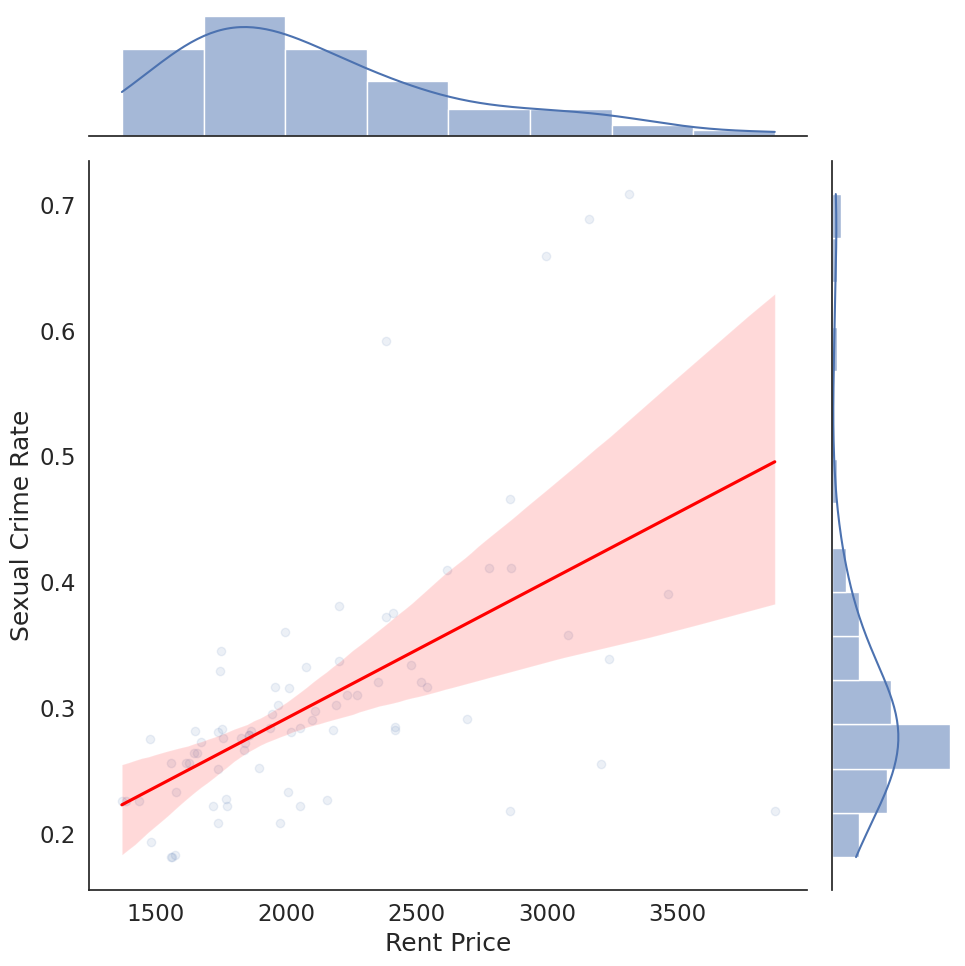

In [174]:
sns.jointplot(data=mergedDF, # plot a scatterplot with a regression line and two histograms
                x='rent price', # set the x axis to be the years of schooling
                y='sexual crime', # set the y axis to be the hourly wage
                kind="reg",  # set the kind of plot to be a regression plot
                scatter_kws=dict(alpha=0.1), # set the transparency of the points to be 0.1 (10%)
                line_kws=dict(color='red'), # set the color of the regression line to red
                height=10) # set the height of the plot to be 10 inches

plt.xlabel('Rent Price') # add a label to the x axis
plt.ylabel('Sexual Crime Rate') # add a label to the y axis

Text(0.5, 1.0, 'Correlation Matrix')

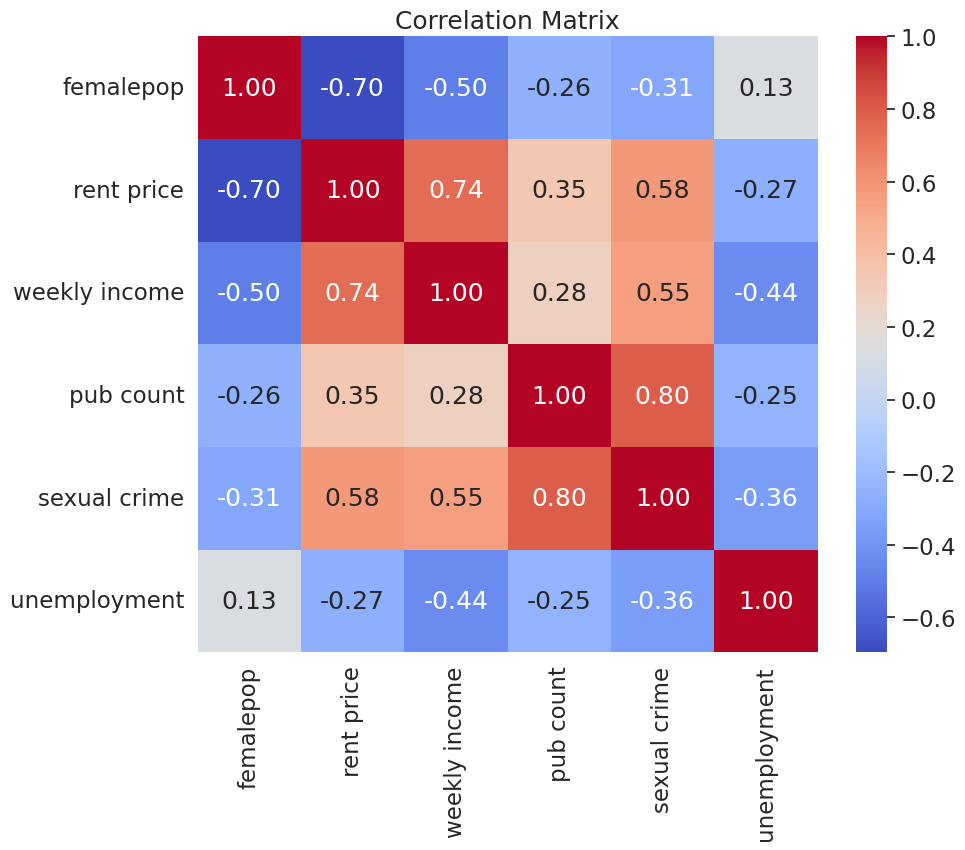

In [175]:
sns.heatmap(mergedDF[['femalepop','rent price','weekly income','pub count','sexual crime','unemployment']].corr(), # plot a correlation matrix
            annot=True, # show the correlation values on the plot
            fmt=".2f", # set the format of the correlation values to be two decimal places
            cmap='coolwarm') # set the color palette to be coolwarm (blue for negative correlations, red for positive correlations)

plt.title('Correlation Matrix') # add a title

In [156]:
# calculating VIF
# This function is amended from: https://stackoverflow.com/a/51329496/4667568

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def drop_column_using_vif_(df, list_var_not_to_remove=None, thresh=5):
    '''
    Calculates VIF each feature in a pandas dataframe, and repeatedly drop the columns with the highest VIF
    A constant must be added to variance_inflation_factor or the results will be incorrect

    :param df: the pandas dataframe containing only the predictor features, not the response variable
    :param list_var_not_to_remove: the list of variables that should not be removed even though it has a high VIF. For example, dummy (or indicator) variables represent a categorical variable with three or more categories.
    :param thresh: the max VIF value before the feature is removed from the dataframe
    :return: dataframe with multicollinear features removed
    '''
    while True:
        # adding a constatnt item to the data
        df_with_const = add_constant(df)

        vif_df = pd.Series([variance_inflation_factor(df_with_const.values, i)
               for i in range(df_with_const.shape[1])], name= "VIF",
              index=df_with_const.columns).to_frame()

        # drop the const as const should not be removed
        vif_df = vif_df.drop('const')

        # drop the variables that should not be removed
        if list_var_not_to_remove is not None:
            vif_df = vif_df.drop(list_var_not_to_remove)

        print('Max VIF:', vif_df.VIF.max())

        # if the largest VIF is above the thresh, remove a variable with the largest VIF
        if vif_df.VIF.max() > thresh:
            # If there are multiple variables with the maximum VIF, choose the first one
            index_to_drop = vif_df.index[vif_df.VIF == vif_df.VIF.max()].tolist()[0]
            print('Dropping: {}'.format(index_to_drop))
            df = mergedDF.drop(columns = index_to_drop)
        else:
            # No VIF is above threshold. Exit the loop
            break

    return df

In [176]:
ind_vars=['femalepop','rent price','weekly income', 'pub count','sexual crime','unemployment']

vif = drop_column_using_vif_(mergedDF[ind_vars], thresh=5)
print("The columns remaining after VIF selection are:")
print(vif.columns)

MissingDataError: exog contains inf or nans

In [162]:
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col

model1 = ols('Q("sexual crime") ~  femalepop + Q("rent price") + Q("weekly income") + Q("pub count") + unemployment', data=mergedDF).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:      Q("sexual crime")   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     36.62
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           7.01e-17
Time:                        23:26:41   Log-Likelihood:                 106.75
No. Observations:                  65   AIC:                            -201.5
Df Residuals:                      59   BIC:                            -188.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0334      0

In [177]:
# Create dataframes for specific occupations

B1 = mergedDF[mergedDF['BoroughName'] == 'Brent']
B2 = mergedDF[mergedDF['BoroughName'] == 'Camden']
B3 = mergedDF[mergedDF['BoroughName'] == 'Islington']
B4 = mergedDF[mergedDF['BoroughName'] == 'Hackney']
B5 = mergedDF[mergedDF['BoroughName'] == 'Tower Hamlets']
B6 = mergedDF[mergedDF['BoroughName'] == 'Greenwich']
B7 = mergedDF[mergedDF['BoroughName'] == 'Southwark']
B8 = mergedDF[mergedDF['BoroughName'] == 'Lambeth']
B9 = mergedDF[mergedDF['BoroughName'] == 'Hammersmith and Fulham']
B10 = mergedDF[mergedDF['BoroughName'] == 'Kensington and Chelsea']
B11 = mergedDF[mergedDF['BoroughName'] == 'Westminister']

# Full sample model
model_full = ols('Q("sexual crime") ~  femalepop + Q("rent price") + Q("weekly income") + Q("pub count") + unemployment', data=mergedDF).fit()

# Initialize lists for filtered models and their names
filtered_models = [model_full]
filtered_model_names = ['Full Sample']

# List of borough DataFrames and their names
borough_dataframes = [
    (B1, 'Brent'),
    (B2, 'Camden'),
    (B3, 'Islington'),
    (B4, 'Hackney'),
    (B5, 'Tower Hamlets'),
    (B6, 'Greenwich'),
    (B7, 'Southwark'),
    (B8, 'Lambeth'),
    (B9, 'Hammersmith and Fulham'),
    (B10, 'Kensington and Chelsea'),
    (B11, 'Westminister')
]

# Models for specific professions - conditionally fit models only if dataframe is not empty
for df_borough, name_borough in borough_dataframes:
    if not df_borough.empty:
        try:
            model = ols('Q("sexual crime") ~  femalepop + Q("rent price") + Q("weekly income") + Q("pub count") + unemployment', data=df_borough).fit()
            filtered_models.append(model)
            filtered_model_names.append(name_borough)
        except Exception as e:
            print(f"Could not fit model for {name_borough}: {e}")
    else:
        print(f"Skipping model for {name_borough} as its DataFrame is empty.")

# A regression table containing the results of each model in a separate column
table_exercise = summary_col(
      filtered_models,
      stars=True,
      float_format='%0.3f',
      model_names=filtered_model_names,
      info_dict={"N":lambda x: "{0:d}".format(int(x.nobs))})

print(table_exercise)


Skipping model for Westminister as its DataFrame is empty.

                   Full Sample Brent  Camden Islington Hackney Tower Hamlets Greenwich Southwark Lambeth Hammersmith and Fulham Kensington and Chelsea
------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept          -0.033      0.615  -1.969 -29.839   4.200   -1.483        0.045     5.370     3.283   -10.032                -1.874                
                   (0.113)     (inf)  (inf)  (inf)     (inf)   (inf)         (inf)     (inf)     (inf)   (inf)                  (inf)                 
femalepop          0.000*      -0.000 0.000  0.000     -0.000  0.000         -0.000    -0.000    -0.000  0.000                  0.000                 
                   (0.000)     (inf)  (inf)  (inf)     (inf)   (inf)         (inf)     (inf)     (inf)   (inf)                  (inf)                 
Q("rent price")    0.000*      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, sel